In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import ExponentialSmoothing, ARIMA
from darts.metrics import mape, rmse, mae, r2_score, mse



ImportError: cannot import name 'TimeSeries' from 'darts' (D:\Users\anast\PycharmProjects\ProphetForecast\.venv\Lib\site-packages\darts\__init__.py)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("cleaned_timeseries.csv")

In [3]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [4]:
df.head()

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


## Arima Model

In [5]:
df = df.set_index("date")

train = df.loc["2013-01-01":"2013-12-31"]
test = df.loc["2014-01-01":"2014-03-31"]

In [6]:
# Arima Model training
arima_model = ARIMA(train["unit_sales"], order=(5, 1, 0))
arima_result = arima_model.fit()

arima_result.summary()

D:\Users\anast\PycharmProjects\ProphetForecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\Users\anast\PycharmProjects\ProphetForecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\Users\anast\PycharmProjects\ProphetForecast\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             unit_sales   No. Observations:                  364
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2350.607
Date:                Wed, 01 Jul 2026   AIC                           4713.214
Time:                        02:04:30   BIC                           4736.581
Sample:                    01-02-2013   HQIC                          4722.502
                         - 12-31-2013                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3798      0.046     -8.340      0.000      -0.469      -0.291
ar.L2         -0.6410      0.050    -12.930      0.000      -0.738      -0.544
ar.L3         -0.4340      0.056     -7.769      0.000      -0.543      -0.325
ar.L4         -0.3403      0.053     -6.433      0.000      -0.444      -0.237
ar.L5         -0.4592      0.050     -9.108      0.000      -0.558      -0.360
sigma2      2.454e+04   1849.646     13.269      0.000    2.09e+04    2.82e+04
===================================================================================
Ljung-Box (L1) (Q):                  15.18   Jarque-Bera (JB):                 1.26
Prob(Q):                              0.00   Prob(JB):                         0.53
Heteroskedasticity (H):               0.99   Skew:                             0.13
Prob(H) (two-sided):                  0.93   Kurtosis:                         3.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
arima_forecast = arima_result.forecast(steps=len(test))

In [8]:
df = df.asfreq("D")

In [9]:
train = df.loc["2013-01-01":"2013-12-31"]
test = df.loc["2014-01-01":"2014-03-31"]

In [10]:
mae = mean_absolute_error(test["unit_sales"], arima_forecast)
rmse = np.sqrt(mean_squared_error(test["unit_sales"], arima_forecast))
r2 = r2_score(test["unit_sales"], arima_forecast)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 144.33
RMSE: 186.45
R²: 0.0405


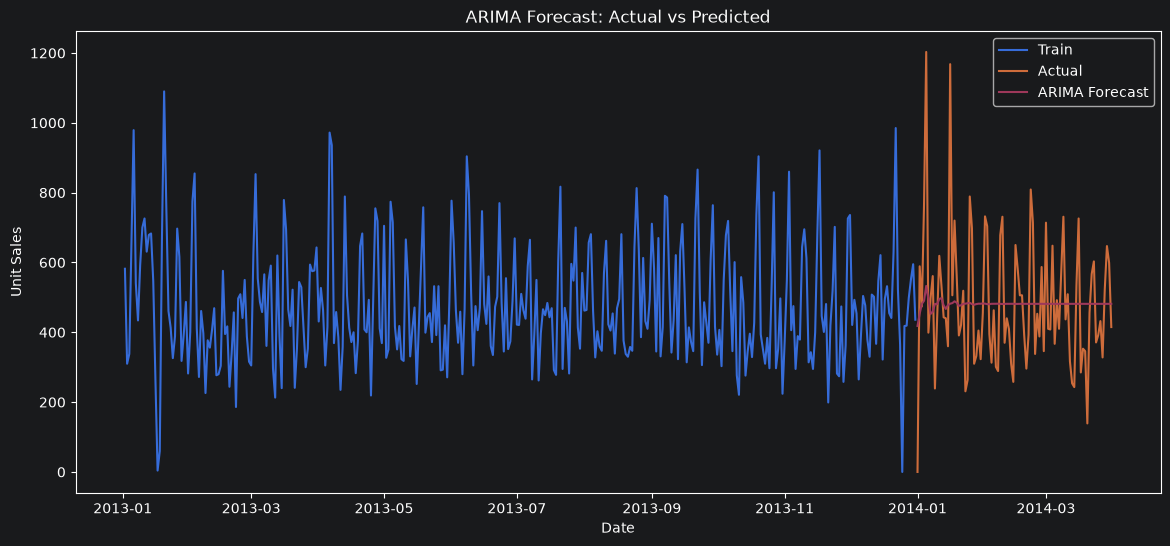

In [11]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train["unit_sales"], label="Train")
plt.plot(test.index, test["unit_sales"], label="Actual")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")

plt.title("ARIMA Forecast: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.show()

The ARIMA model produced relatively weak forecasting results. The forecast remains almost flat and does not capture the strong fluctuations and sales peaks observed in the test period. This is reflected in the evaluation metrics, with a high MAE and RMSE and a very low R² score. Compared to the machine learning models, ARIMA performs considerably worse on this dataset.

## Exponential Smoothing

In [12]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# daily sales figures are included => a weekly seasonality
exp_model = ExponentialSmoothing(
    train["unit_sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
)

exp_result = exp_model.fit()

In [13]:
exp_forecast = exp_result.forecast(steps=len(test))

In [14]:
mae = mean_absolute_error(test["unit_sales"], exp_forecast)
rmse = np.sqrt(mean_squared_error(test["unit_sales"], exp_forecast))
r2 = r2_score(test["unit_sales"], exp_forecast)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 98.43
RMSE: 150.41
R²: 0.3756


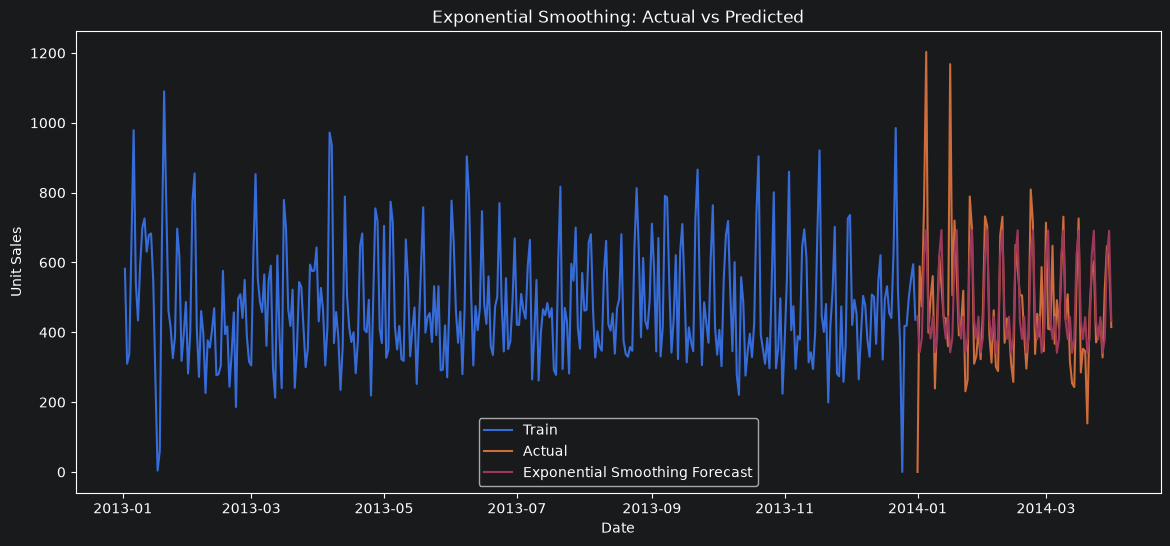

In [15]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train["unit_sales"], label="Train")
plt.plot(test.index, test["unit_sales"], label="Actual")
plt.plot(test.index, exp_forecast, label="Exponential Smoothing Forecast")

plt.title("Exponential Smoothing: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()

plt.show()

The Exponential Smoothing model performed considerably better than the ARIMA model. It successfully captured the weekly seasonal pattern and followed the overall fluctuations in unit sales. However, the model still smoothed the predictions, resulting in an underestimation of large sales peaks and an overestimation of very low values. Overall, the model achieved a moderate forecasting performance with an MAE of 98.43, an RMSE of 150.41, and an R² score of 0.3756. While it outperformed ARIMA, it remained less accurate than the machine learning models tested earlier.

## Sarima

In [18]:
train_ts = train["unit_sales"]
test_ts = test["unit_sales"]

In [19]:
sarima_model = SARIMAX(
    train_ts,
    order=(1,1,1),
    seasonal_order=(1,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

In [20]:
# Prediction for the test period
sarima_forecast = sarima_fit.forecast(steps=len(test_ts))

In [21]:
mae = mean_absolute_error(test_ts, sarima_forecast)
rmse = np.sqrt(mean_squared_error(test_ts, sarima_forecast))
r2 = r2_score(test_ts, sarima_forecast)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 98.89
RMSE: 151.02
R²: 0.3705


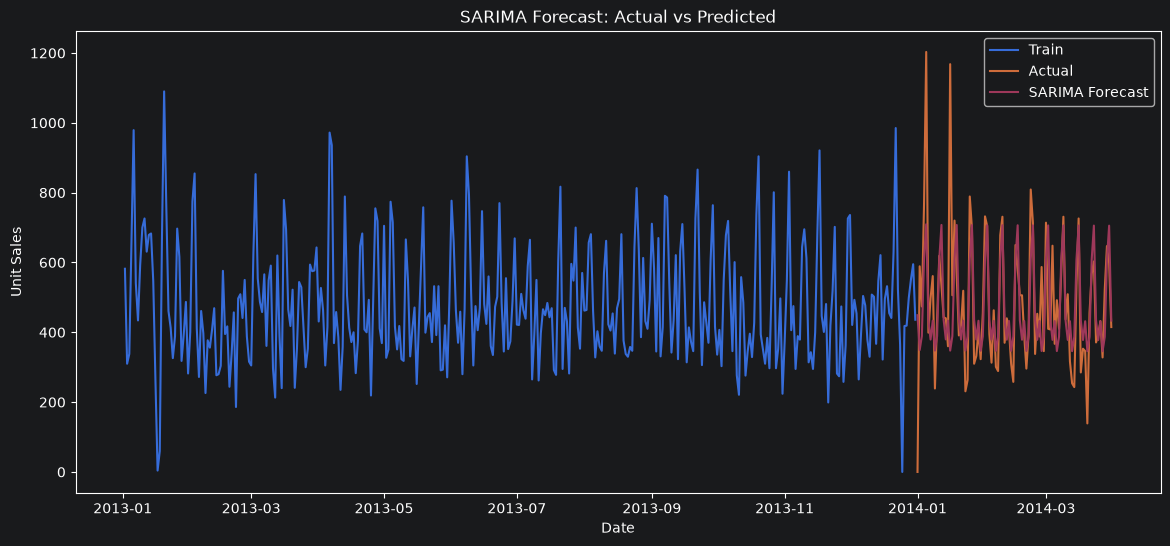

In [22]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train["unit_sales"], label="Train")
plt.plot(test.index, test["unit_sales"], label="Actual")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")

plt.title("SARIMA Forecast: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()

plt.show()

The SARIMA model improved substantially over the non-seasonal ARIMA model by capturing the weekly seasonal structure of the sales data. Its forecast follows the recurring fluctuations more closely, although extreme peaks are still underestimated. The performance is comparable to Exponential Smoothing, but slightly weaker in terms of MAE, RMSE, and R². Overall, SARIMA performs reasonably well as a statistical forecasting model, but it does not outperform the machine learning models.

## Prophet

In [23]:
from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import matplotlib.pyplot as plt

D:\Users\anast\PycharmProjects\ProphetForecast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
train_prophet = train.reset_index()[["date", "unit_sales"]]
test_prophet = test.reset_index()[["date", "unit_sales"]]

train_prophet.columns = ["ds", "y"]
test_prophet.columns = ["ds", "y"]

In [25]:
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train_prophet)

02:39:01 - cmdstanpy - INFO - Chain [1] start processing
02:39:03 - cmdstanpy - INFO - Chain [1] done processing


In [26]:
future = test_prophet[["ds"]]

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2014-01-01,471.089203,303.250487,589.095379,471.089203,471.089203,-26.523638,-26.523638,-26.523638,-26.523638,-26.523638,-26.523638,0.0,0.0,0.0,444.565566
1,2014-01-02,471.058473,193.530218,486.850296,471.058473,471.058473,-128.994191,-128.994191,-128.994191,-128.994191,-128.994191,-128.994191,0.0,0.0,0.0,342.064282
2,2014-01-03,471.027743,231.308534,534.257986,471.026709,471.027743,-88.094482,-88.094482,-88.094482,-88.094482,-88.094482,-88.094482,0.0,0.0,0.0,382.933261
3,2014-01-04,470.997012,465.079710,765.487099,470.993223,470.997831,149.464893,149.464893,149.464893,149.464893,149.464893,149.464893,0.0,0.0,0.0,620.461905
4,2014-01-05,470.966282,552.667573,835.748430,470.957700,470.969549,221.153210,221.153210,221.153210,221.153210,221.153210,221.153210,0.0,0.0,0.0,692.119491


In [27]:
prophet_forecast = forecast["yhat"]

mae = mean_absolute_error(test_prophet["y"], prophet_forecast)
rmse = np.sqrt(mean_squared_error(test_prophet["y"], prophet_forecast))
r2 = r2_score(test_prophet["y"], prophet_forecast)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 98.36
RMSE: 150.47
R²  : 0.3751


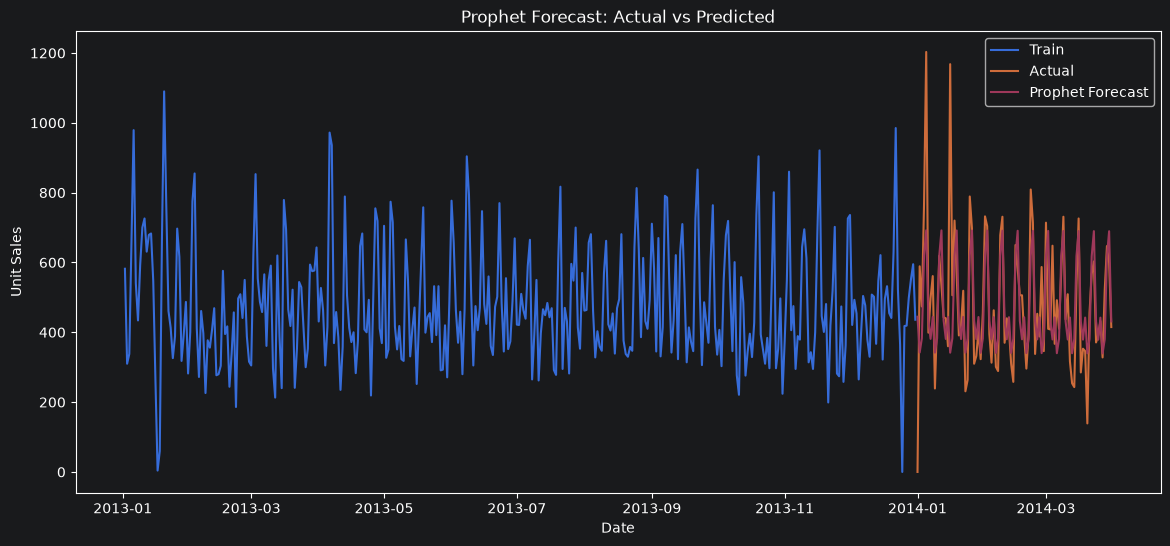

In [28]:
plt.figure(figsize=(14,6))

plt.plot(train.index, train["unit_sales"], label="Train")
plt.plot(test.index, test["unit_sales"], label="Actual")
plt.plot(test.index, prophet_forecast, label="Prophet Forecast")

plt.title("Prophet Forecast: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()

plt.show()

Prophet achieved forecasting performance comparable to Exponential Smoothing and SARIMA. The model successfully captured the weekly seasonal pattern and followed the overall sales trend. Compared with ARIMA, Prophet produced considerably more accurate forecasts. However, like the other statistical models, it tended to smooth extreme fluctuations, underestimating high sales peaks and overestimating very low values. Although Prophet performed well, the machine learning models, particularly Linear Regression, Random Forest, and XGBoost, achieved superior predictive accuracy on this dataset.

In [29]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "ARIMA",
        "SARIMA",
        "Exponential Smoothing",
        "Prophet"
    ],
    "MAE": [
        90.85,
        88.88,
        91.40,
        144.33,
        98.89,
        98.43,
        98.36
    ],
    "RMSE": [
        134.22,
        141.29,
        143.47,
        186.45,
        151.02,
        150.41,
        150.47
    ],
    "R2": [
        0.5028,
        0.4490,
        0.4319,
        0.0405,
        0.3705,
        0.3756,
        0.3751
    ]
})

results.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
0,Linear Regression,90.85,134.22,0.5028
1,Random Forest,88.88,141.29,0.4490
2,XGBoost,91.40,143.47,0.4319
5,Exponential Smoothing,98.43,150.41,0.3756
6,Prophet,98.36,150.47,0.3751
4,SARIMA,98.89,151.02,0.3705
3,ARIMA,144.33,186.45,0.0405


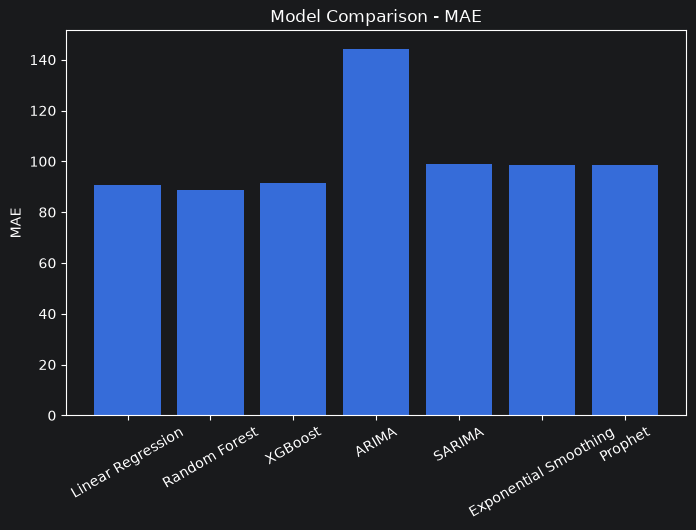

In [30]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["MAE"])

plt.xticks(rotation=30)
plt.ylabel("MAE")
plt.title("Model Comparison - MAE")

plt.show()

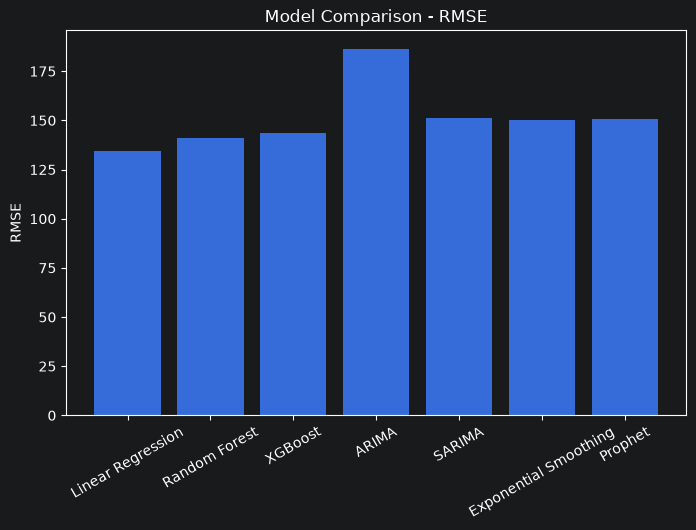

In [31]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["RMSE"])

plt.xticks(rotation=30)
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")

plt.show()

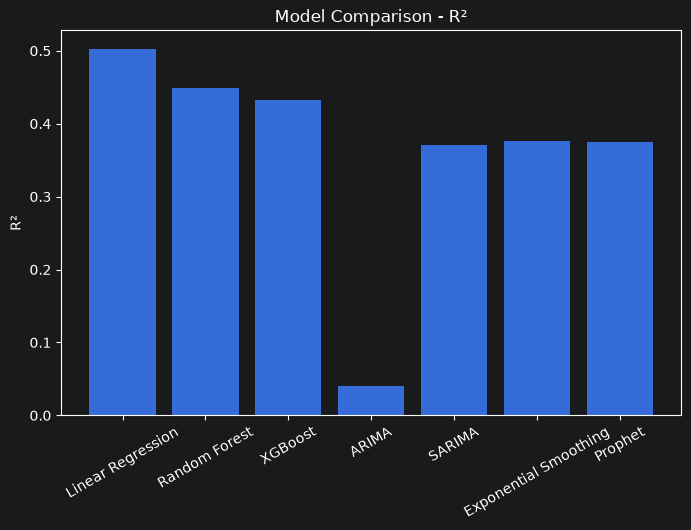

In [32]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2"])

plt.xticks(rotation=30)
plt.ylabel("R²")
plt.title("Model Comparison - R²")

plt.show()

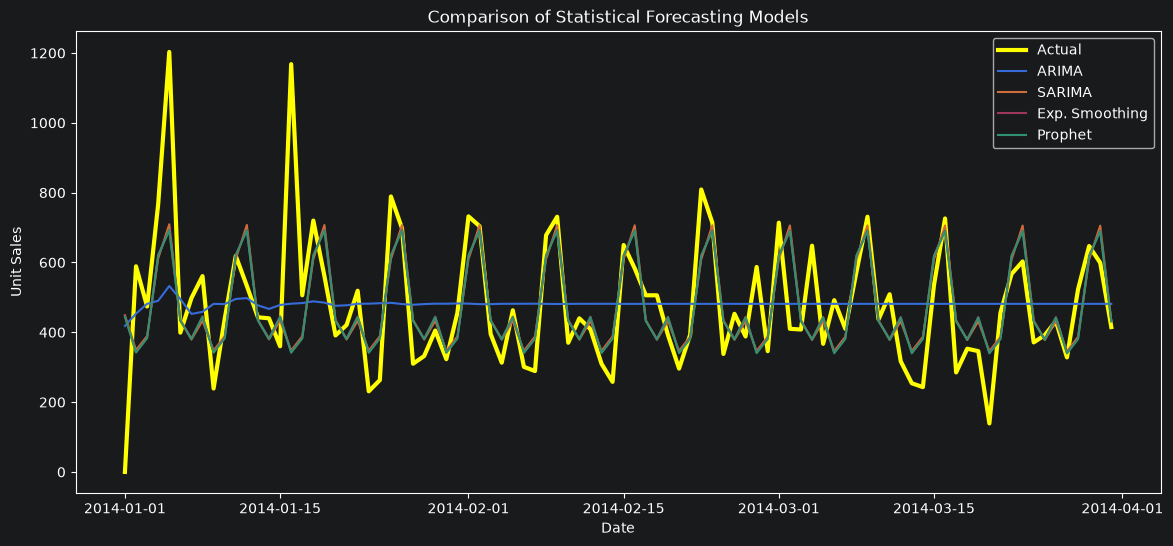

In [41]:
plt.figure(figsize=(14,6))

plt.plot(test.index, test["unit_sales"], label="Actual", color="yellow", linewidth=3)

plt.plot(test.index, arima_forecast, label="ARIMA")
plt.plot(test.index, sarima_forecast, label="SARIMA")
plt.plot(test.index, exp_forecast, label="Exp. Smoothing")
plt.plot(test.index, prophet_forecast, label="Prophet")

plt.title("Comparison of Statistical Forecasting Models")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()

plt.show()

Seven forecasting models were evaluated using MAE, RMSE, and R². Among all approaches, Linear Regression achieved the highest overall performance with the highest R² and the lowest RMSE. Random Forest achieved the lowest MAE but a slightly higher RMSE, indicating that it produced a few larger prediction errors. XGBoost also performed well but did not surpass the simpler Linear Regression model. Among the statistical approaches, Prophet, Exponential Smoothing, and SARIMA produced very similar results and clearly outperformed the basic ARIMA model. Overall, the machine learning models achieved better predictive accuracy than the statistical time series models for this dataset.